# Analysis

## 1. For all algorithms and flagging patterns, the $|V_{\mathrm{inp}}(\tau)|/|V_{\mathrm{true}}(\tau)|$ ratio plot (lower-left panel) shows excellent inpainting performance at approximately $|\tau| \lesssim 800\ \mathrm{ns}$. Within $1000 < |\tau| < 2000\ \mathrm{ns}$, the ratios remain very close to 1, while noticeable deviations from the true data begin to appear at $|\tau| \gtrsim 2000\ \mathrm{ns}$.

## 2. For the ratio histograms restricted to $1000 < |\tau| < 2000\ \mathrm{ns}$ (lower-right panel), the different algorithms show no substantial differences. The `2d` algorithm performs slightly worse than the others, but its ratio distribution is still centered close to 1.

## 3. For the narrowband, full-time flagging case, the $\log_{10}|V(\tau)|$ density distributions ( upper-right panel) show that the `2d_1d` inpainting results closely match the true-data distributions across three different delay ranges. Even at large delays, $3000 < |\tau| < 4000\ \mathrm{ns}$ (green), the inpainted distribution shows only a slight shift relative to the true distribution.

## 4. For the full-band, short-time flagging case, the ratios appear to deviate significantly from one. However, they are actually very close to one, with values around 0.9999999.


## 5. For the narrowband long-time flagging pattern, the 1D+1D algorithm performs noticeably worse than the 2D+1D and other algorithms for baselines (0, 5) and (0, 10). This difference is particularly pronounced for baseline (0, 5) and (0, 10), whereas all algorithms perform well for baseline (0, 1).

## For the wideband long-time flagging pattern at baseline (0, 10), the 1D+1D algorithm also performs noticeably worse than the 2D+1D and other algorithms.



gprlim path:
/Users/alliswell48/gprlim/gprlim/__init__.py

utils_inpaint module path:
/Users/alliswell48/radio_gpr_work/shao1/utils_load.py

gp_utils path:
/Users/alliswell48/radio_gpr_work/shao1/../gp_utils.py


Antenna pair (1, 2) does not have any data associated with it.
Antenna pair (2, 3) does not have any data associated with it.
Antenna pair (3, 4) does not have any data associated with it.
Antenna pair (4, 5) does not have any data associated with it.
Antenna pair (5, 6) does not have any data associated with it.
Antenna pair (6, 7) does not have any data associated with it.
Antenna pair (7, 8) does not have any data associated with it.
Antenna pair (8, 9) does not have any data associated with it.
Antenna pair (9, 10) does not have any data associated with it.
Antenna pair (11, 12) does not have any data associated with it.
Antenna pair (12, 13) does not have any data associated with it.
Antenna pair (13, 14) does not have any data associated with it.
Antenna pair (14, 15) does not have any data associated with it.
Antenna pair (15, 16) does not have any data associated with it.
Antenna pair (16, 17) does not have any data associated with it.
Antenna pair (17, 18) does not have any da

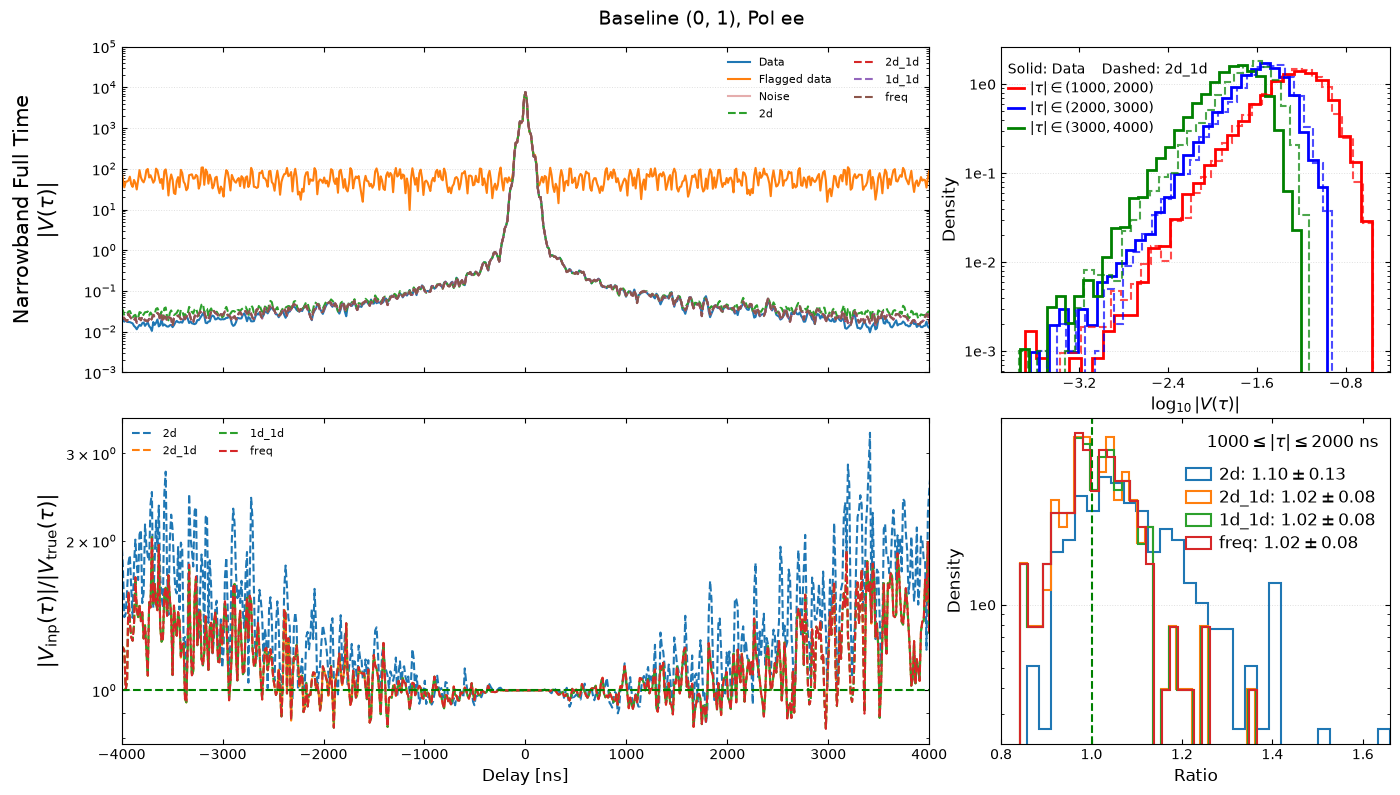

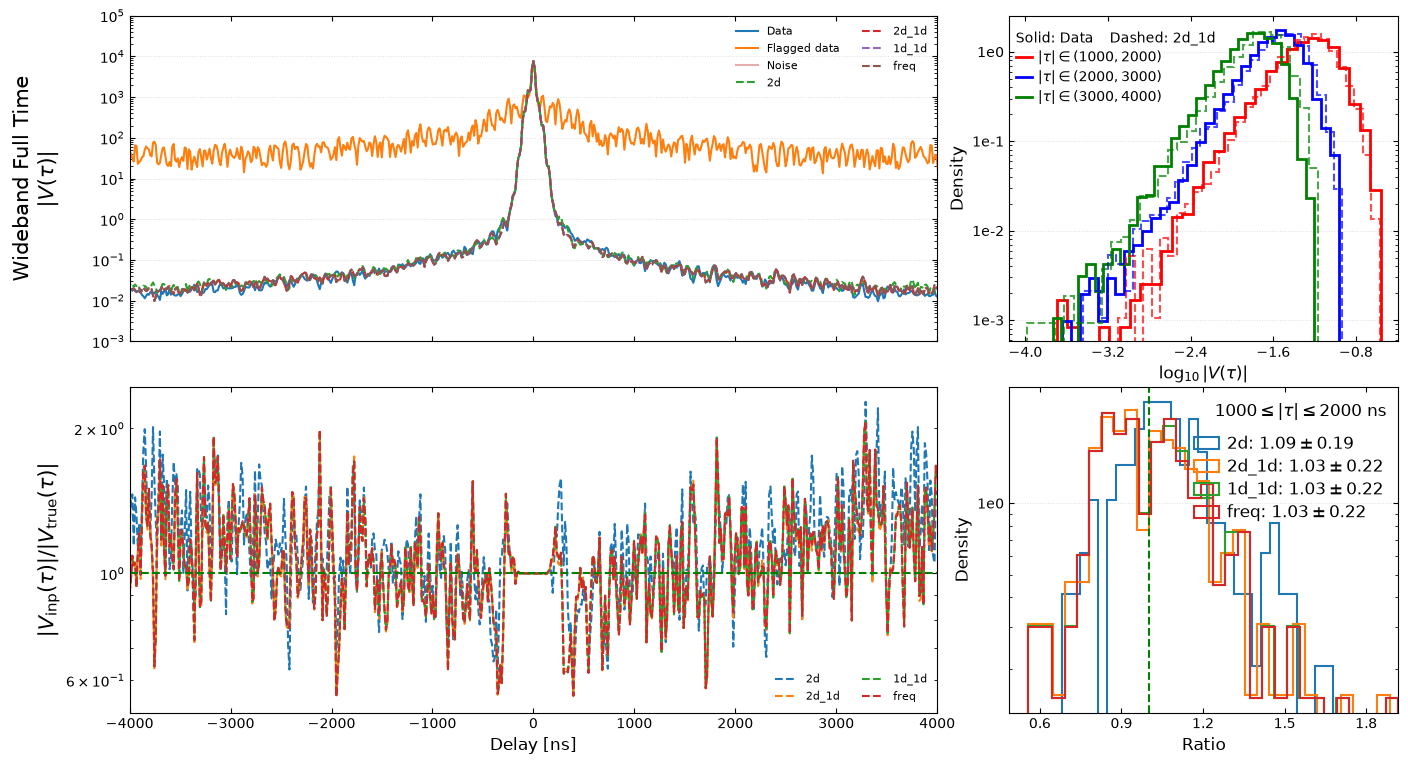

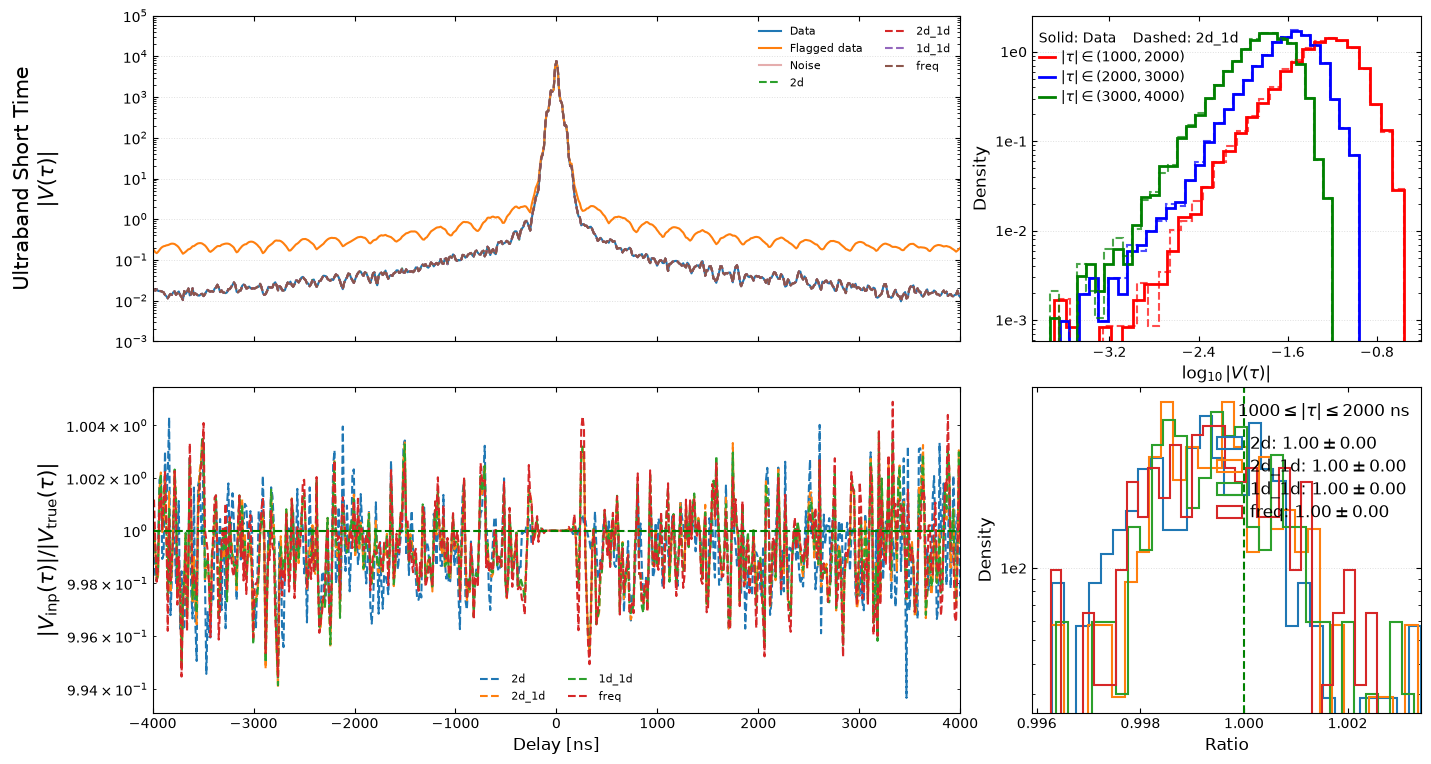

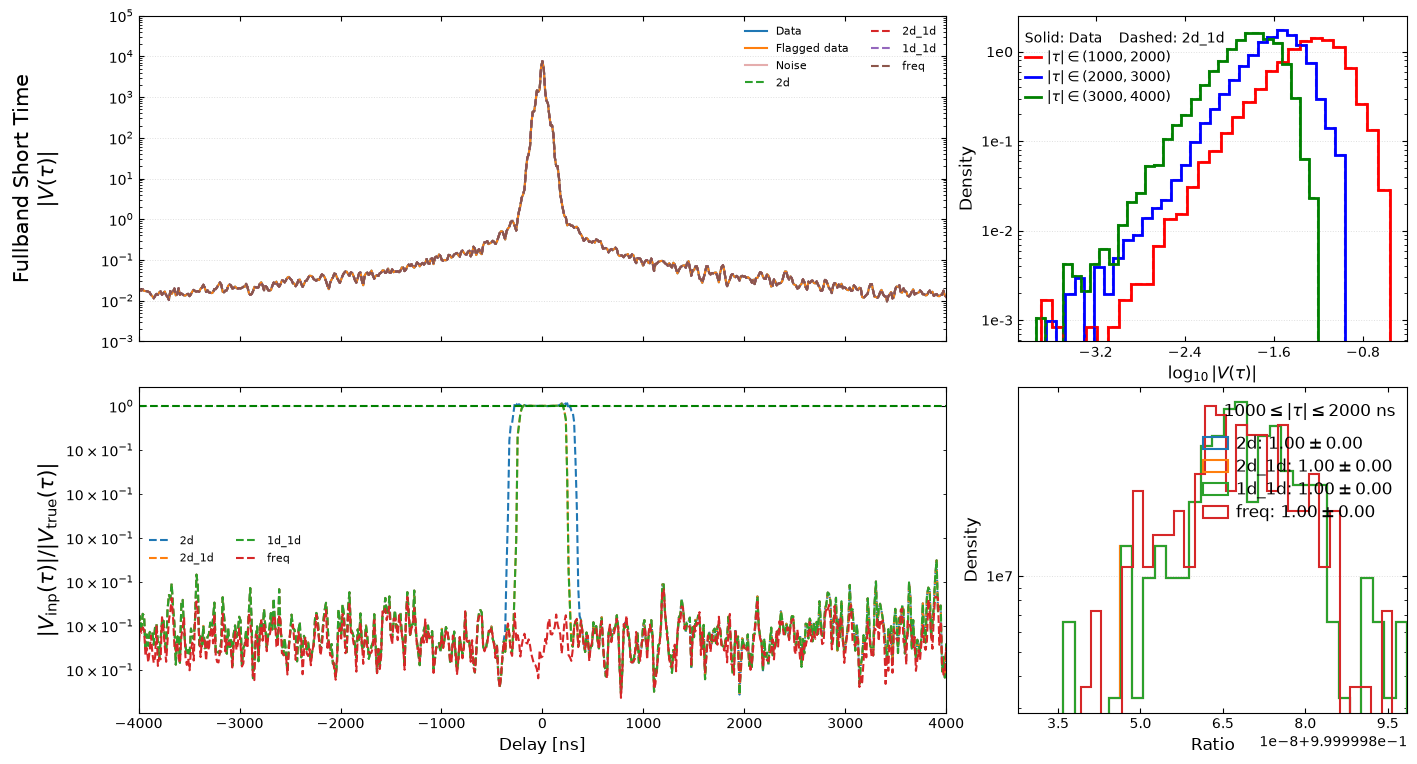

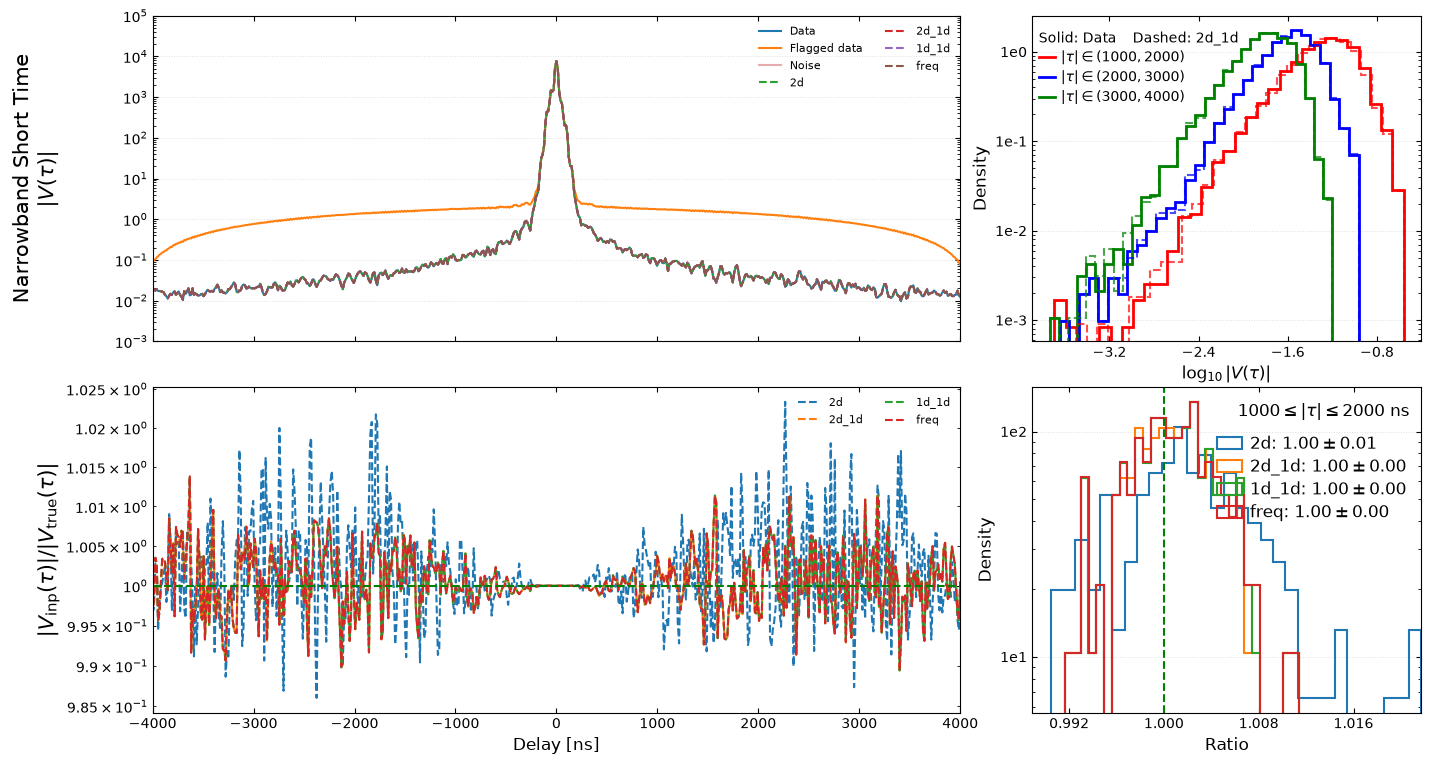

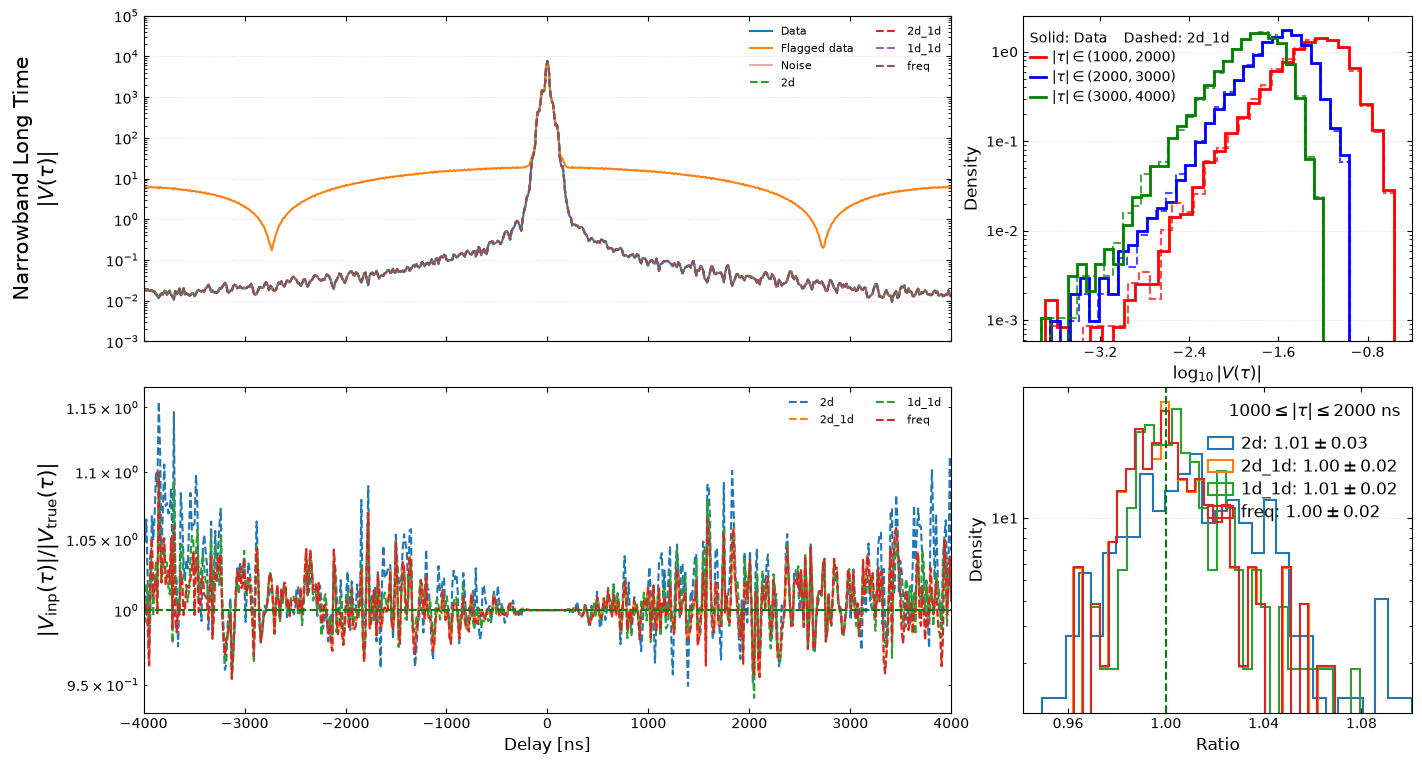

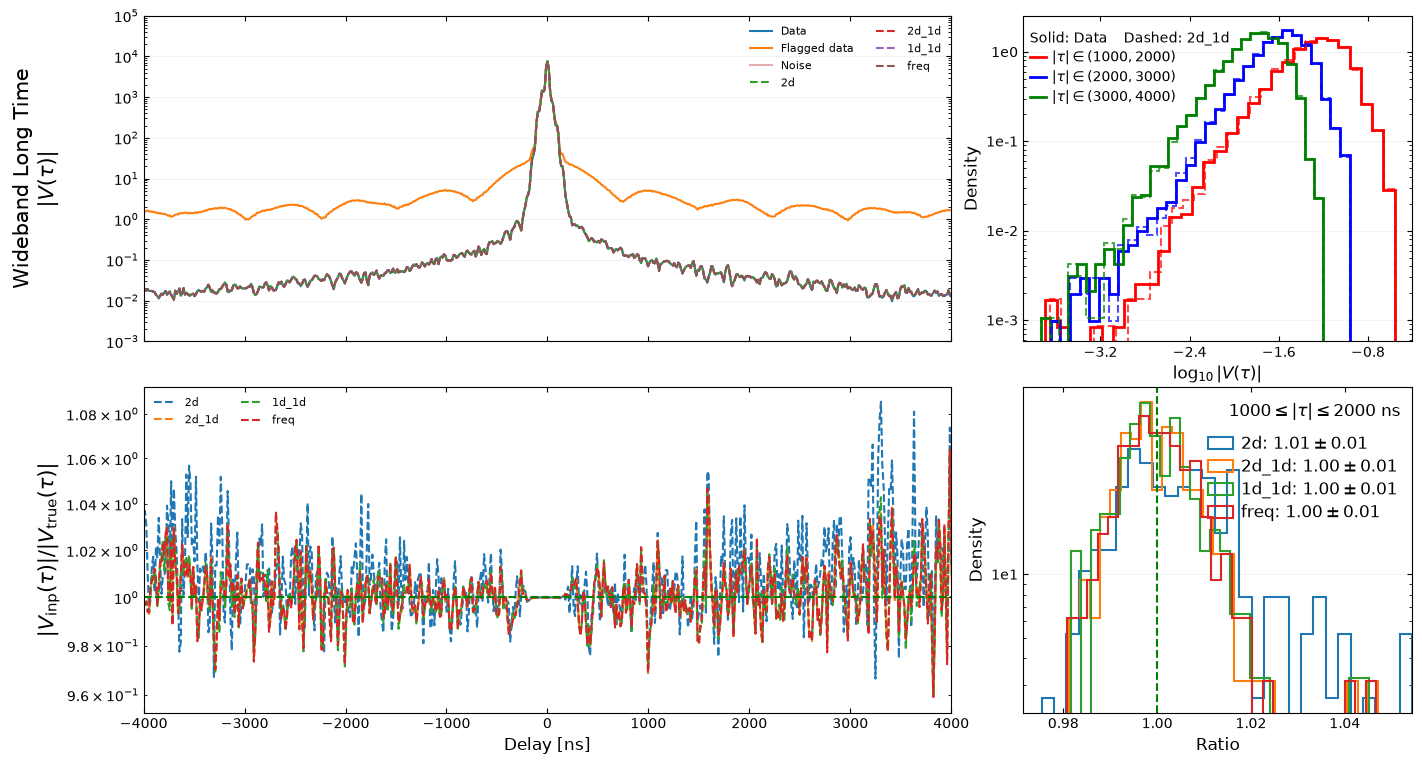

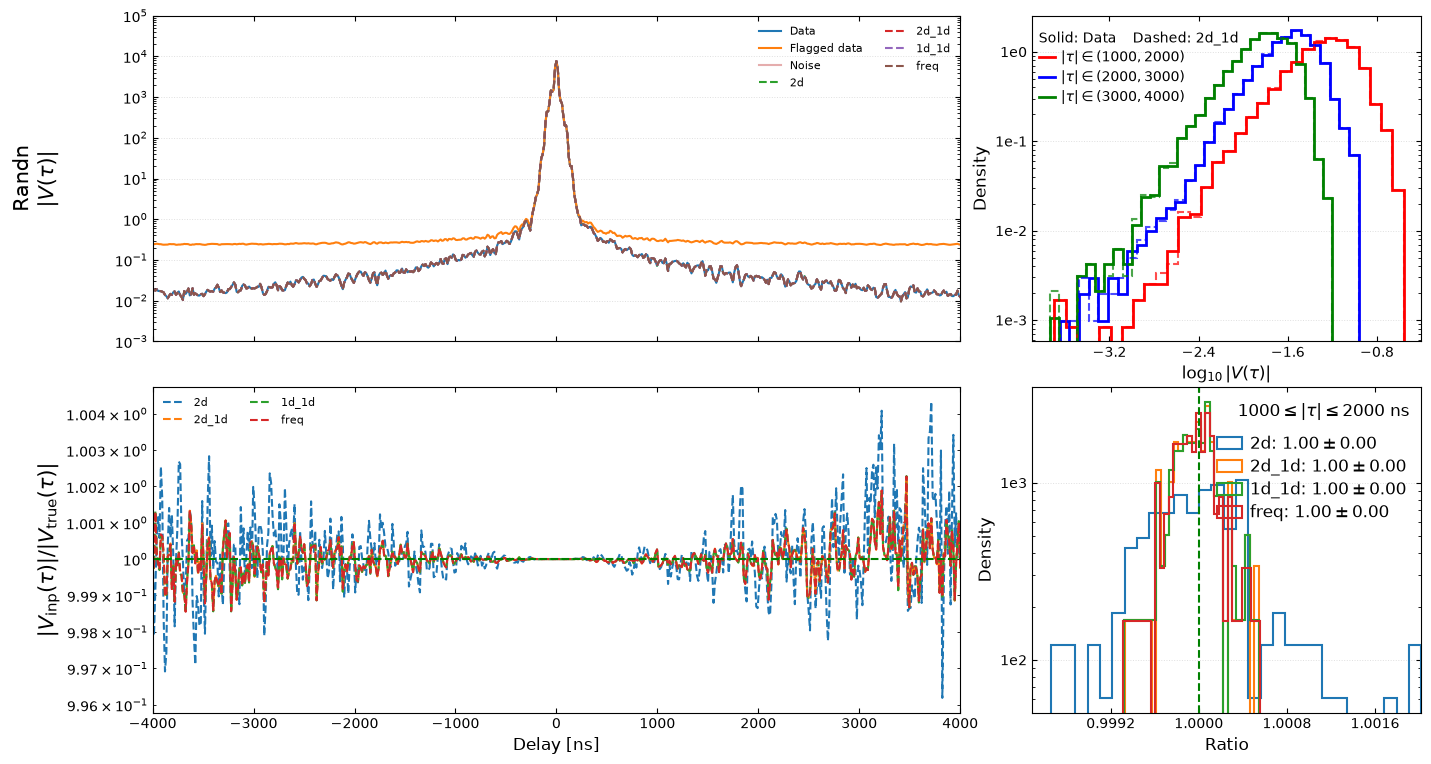

Antenna pair (1, 6) does not have any data associated with it.
Antenna pair (2, 7) does not have any data associated with it.
Antenna pair (3, 8) does not have any data associated with it.
Antenna pair (4, 9) does not have any data associated with it.
Antenna pair (5, 10) does not have any data associated with it.
Antenna pair (11, 16) does not have any data associated with it.
Antenna pair (12, 17) does not have any data associated with it.
Antenna pair (13, 18) does not have any data associated with it.
Antenna pair (14, 19) does not have any data associated with it.
Antenna pair (15, 20) does not have any data associated with it.
Antenna pair (16, 21) does not have any data associated with it.
Antenna pair (23, 28) does not have any data associated with it.
Antenna pair (24, 29) does not have any data associated with it.
Antenna pair (25, 30) does not have any data associated with it.
Antenna pair (26, 31) does not have any data associated with it.
Antenna pair (27, 32) does not hav

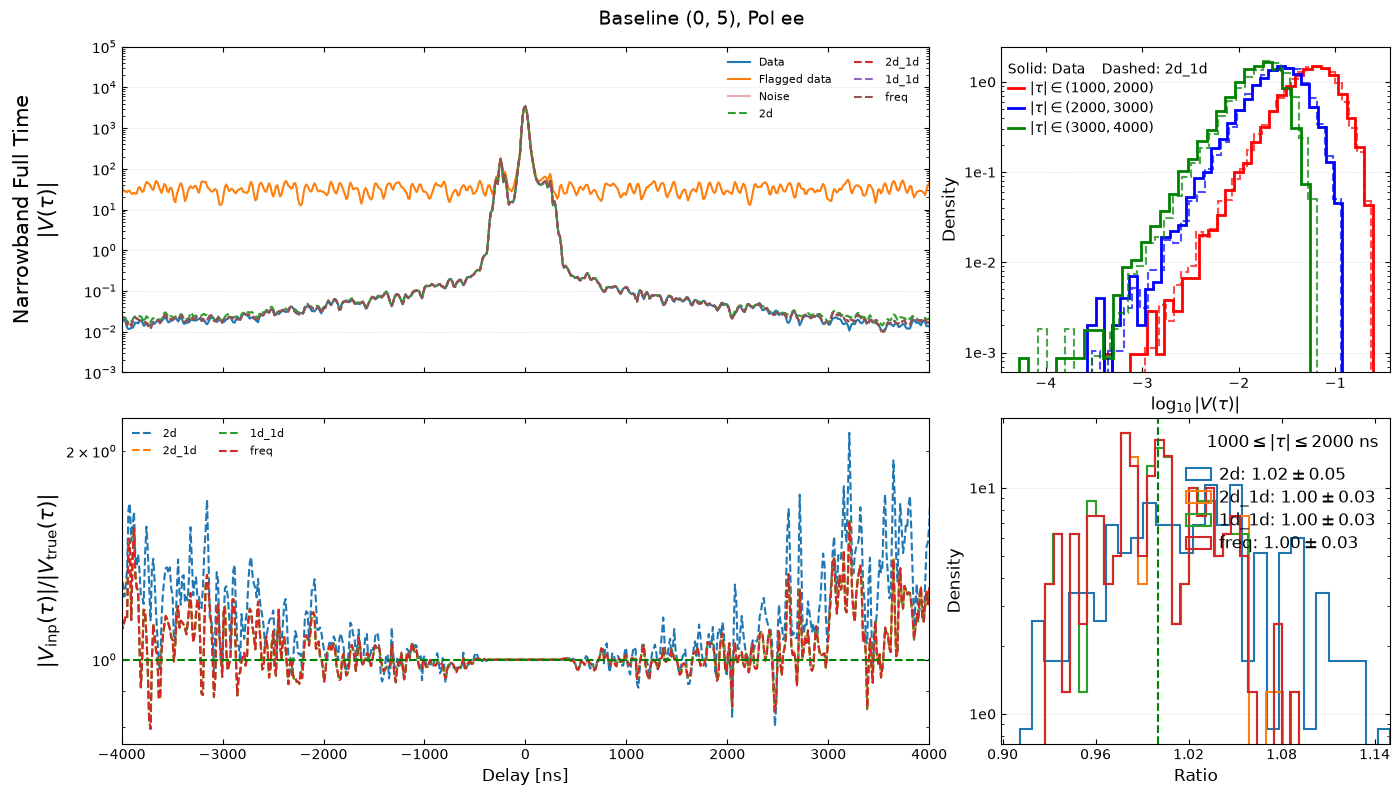

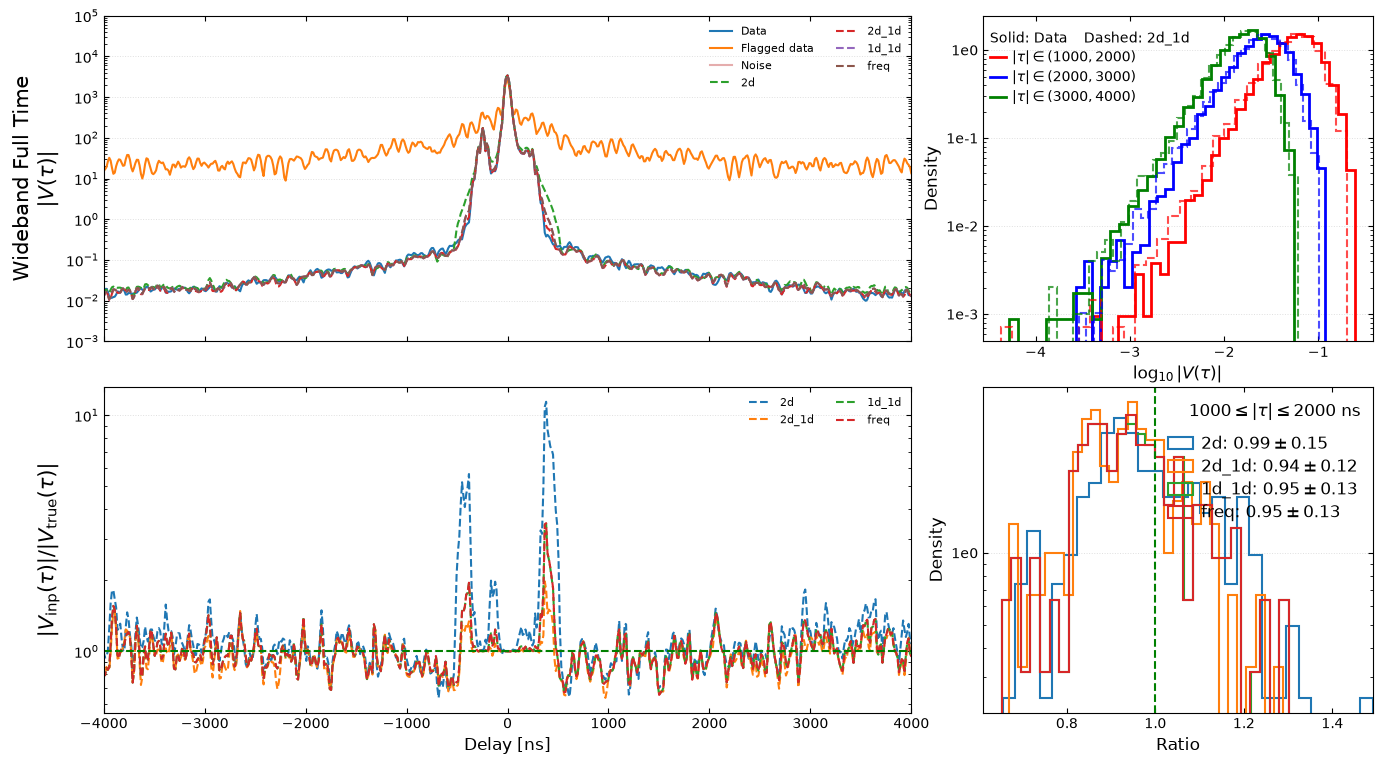

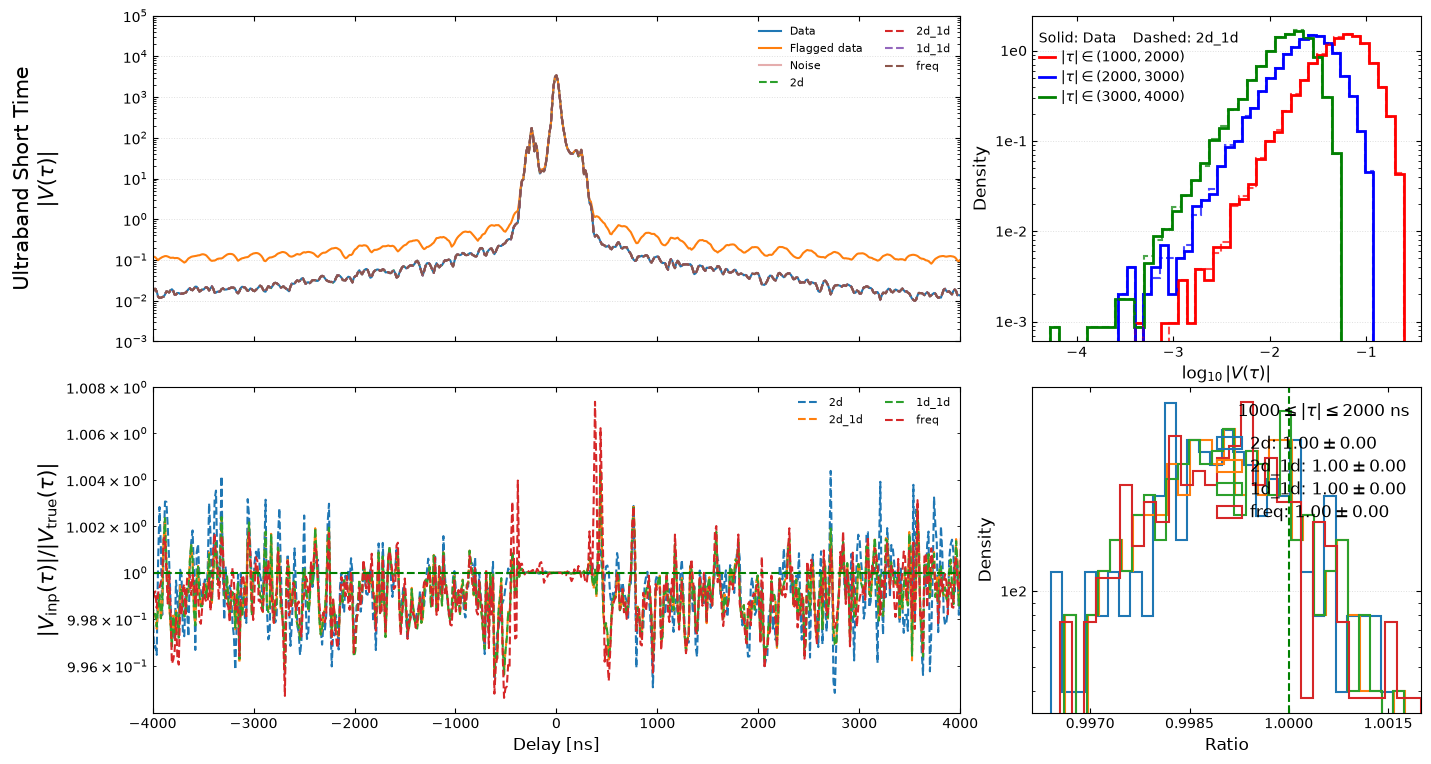

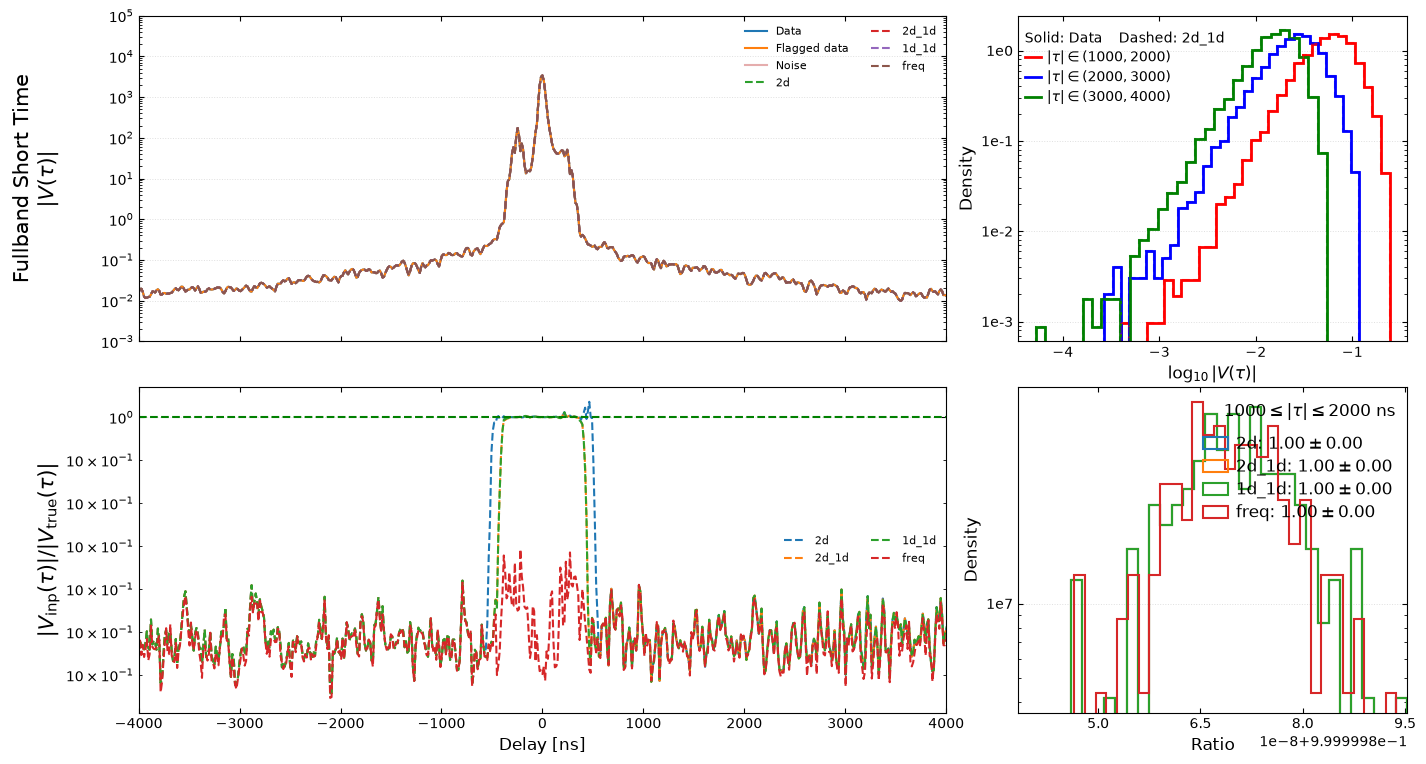

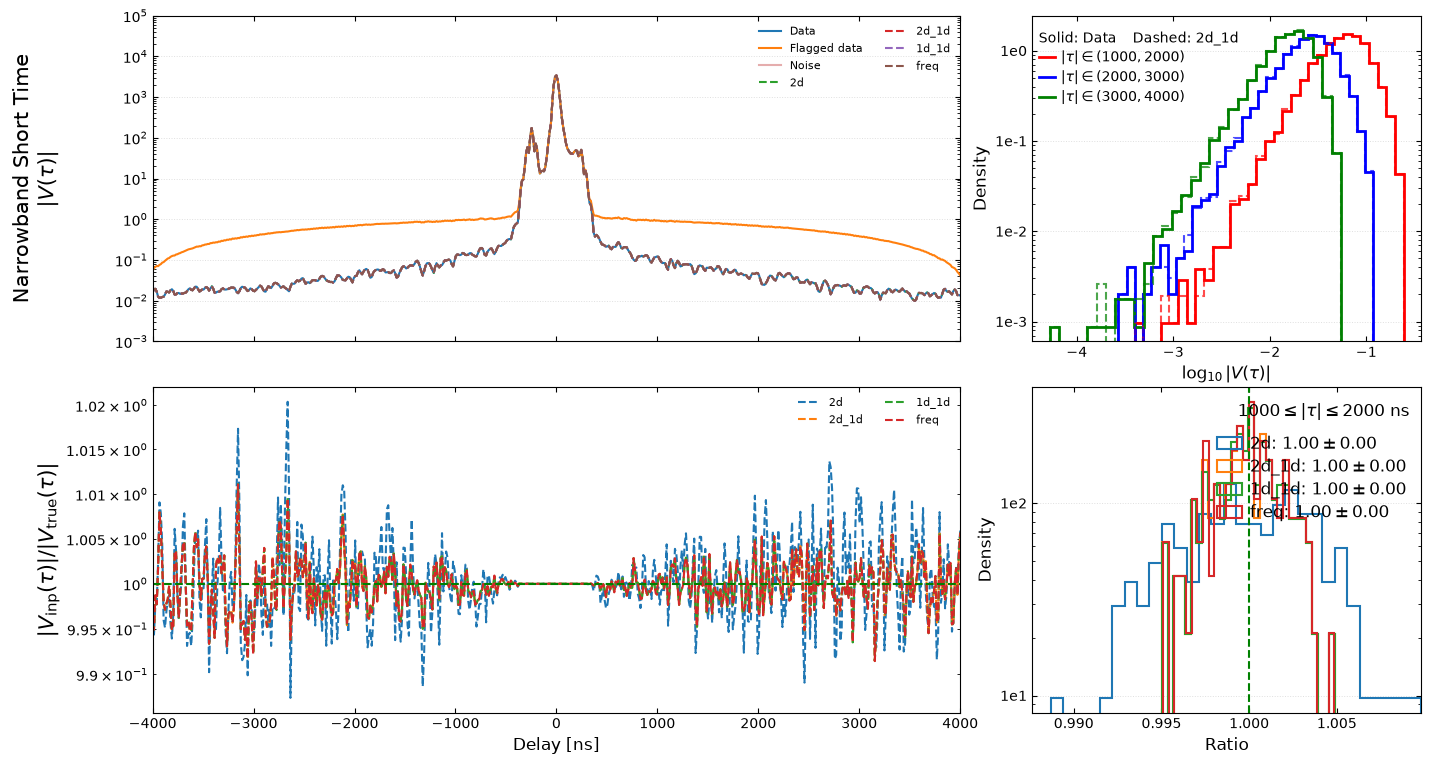

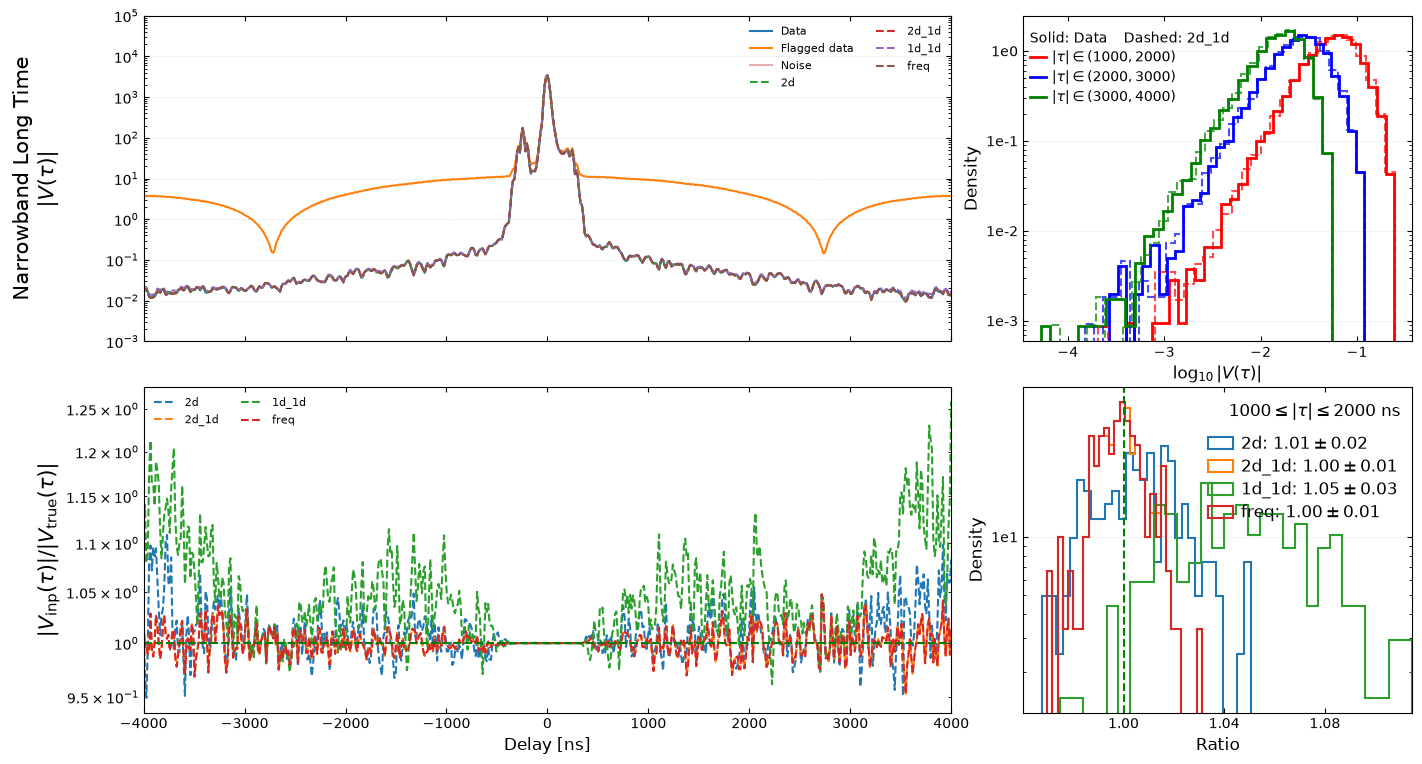

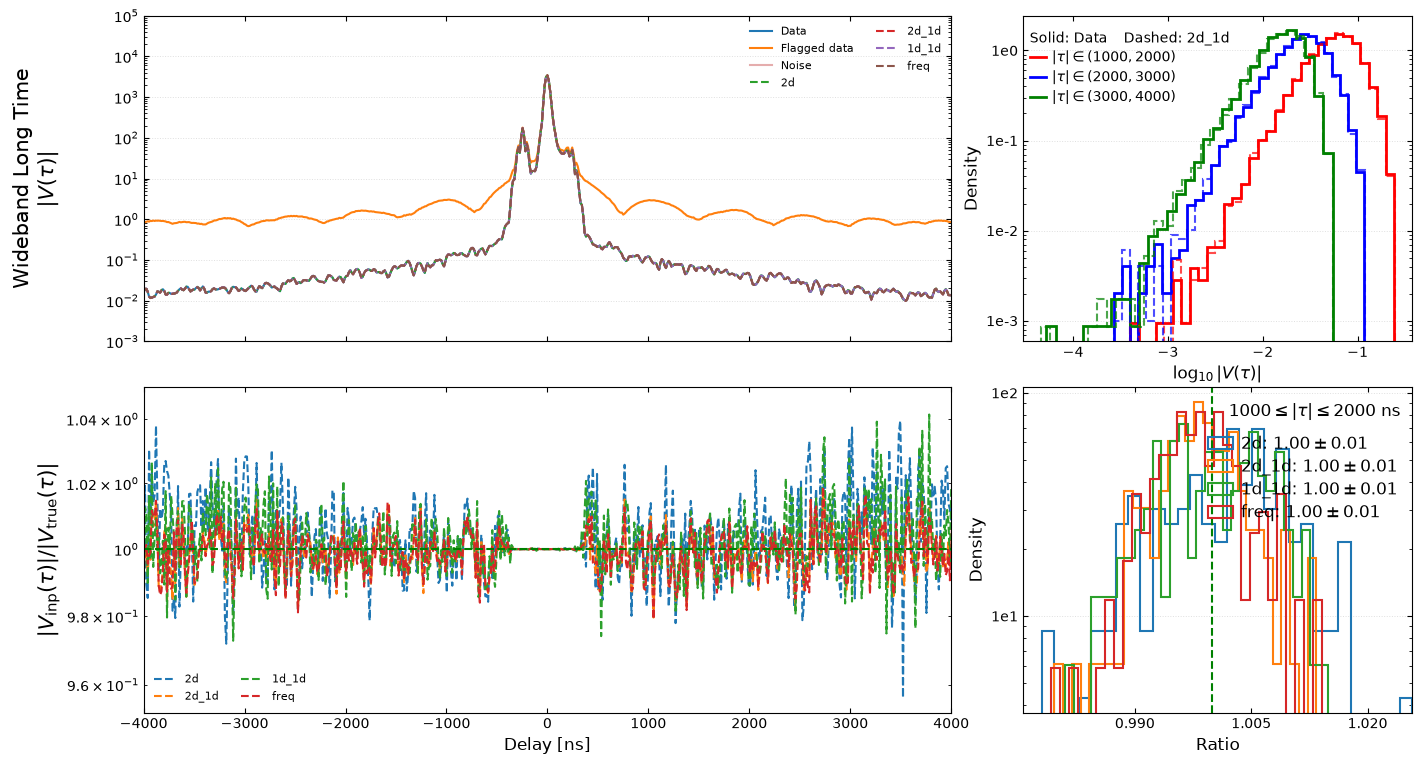

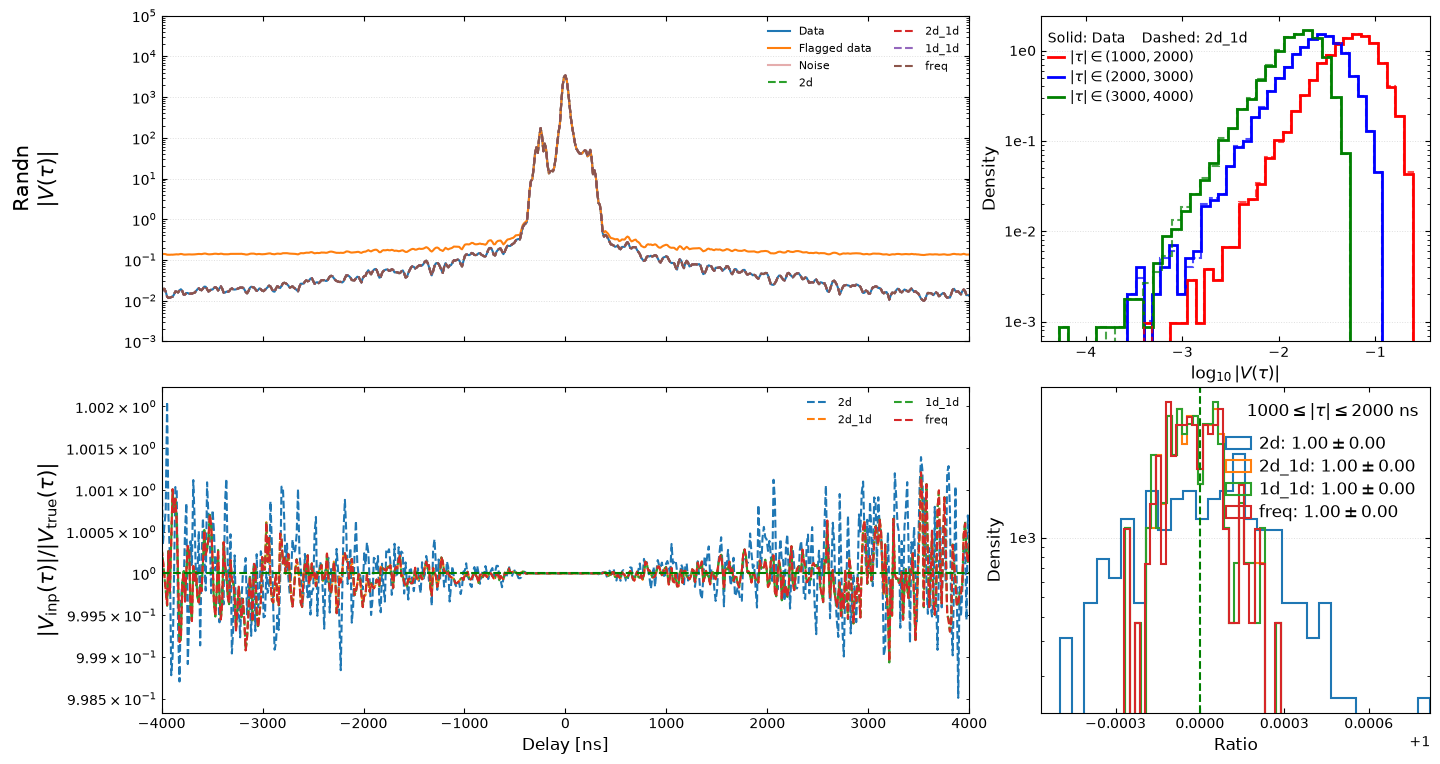

Antenna pair (11, 21) does not have any data associated with it.
Antenna pair (23, 33) does not have any data associated with it.
Antenna pair (36, 46) does not have any data associated with it.
Antenna pair (50, 60) does not have any data associated with it.
Antenna pair (65, 75) does not have any data associated with it.
Antenna pair (81, 91) does not have any data associated with it.
Antenna pair (98, 108) does not have any data associated with it.
Antenna pair (116, 126) does not have any data associated with it.
Antenna pair (135, 145) does not have any data associated with it.


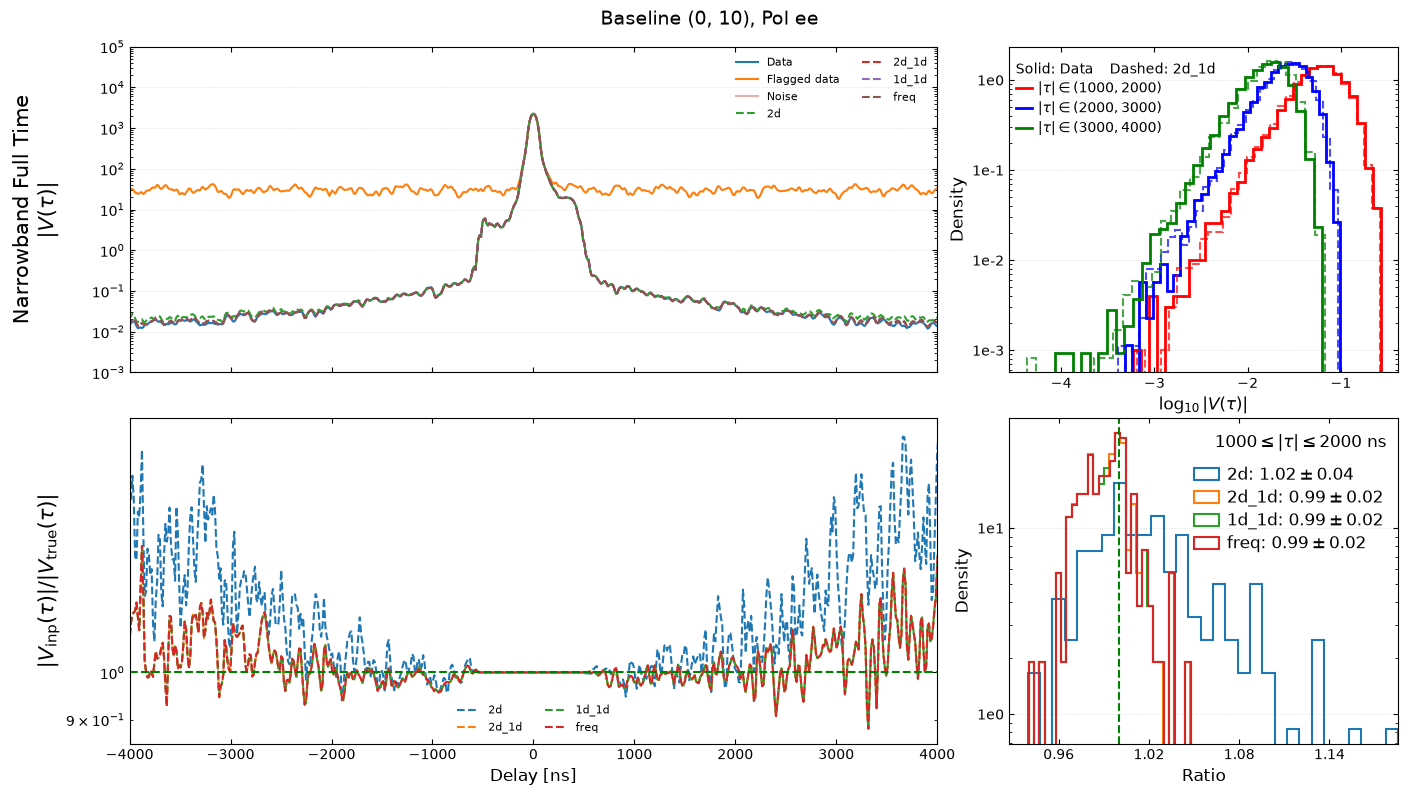

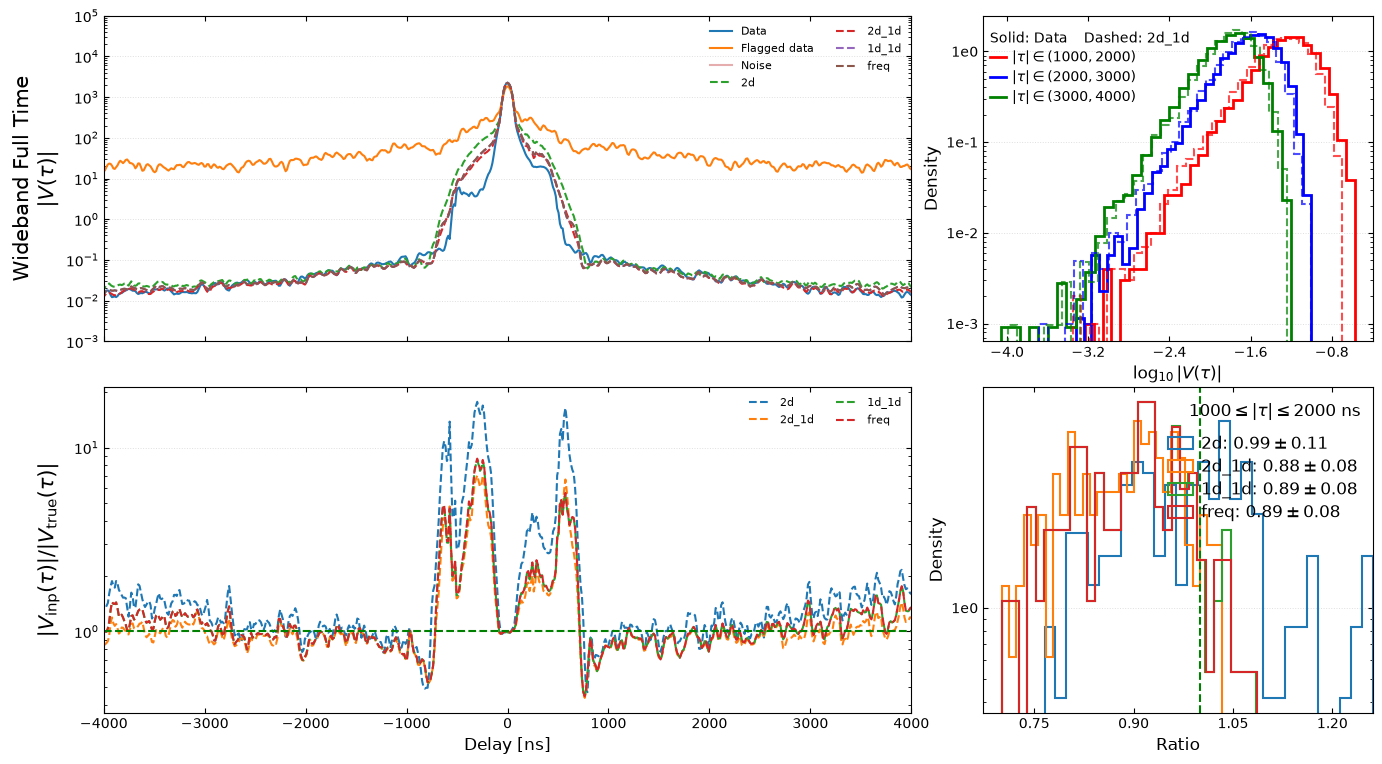

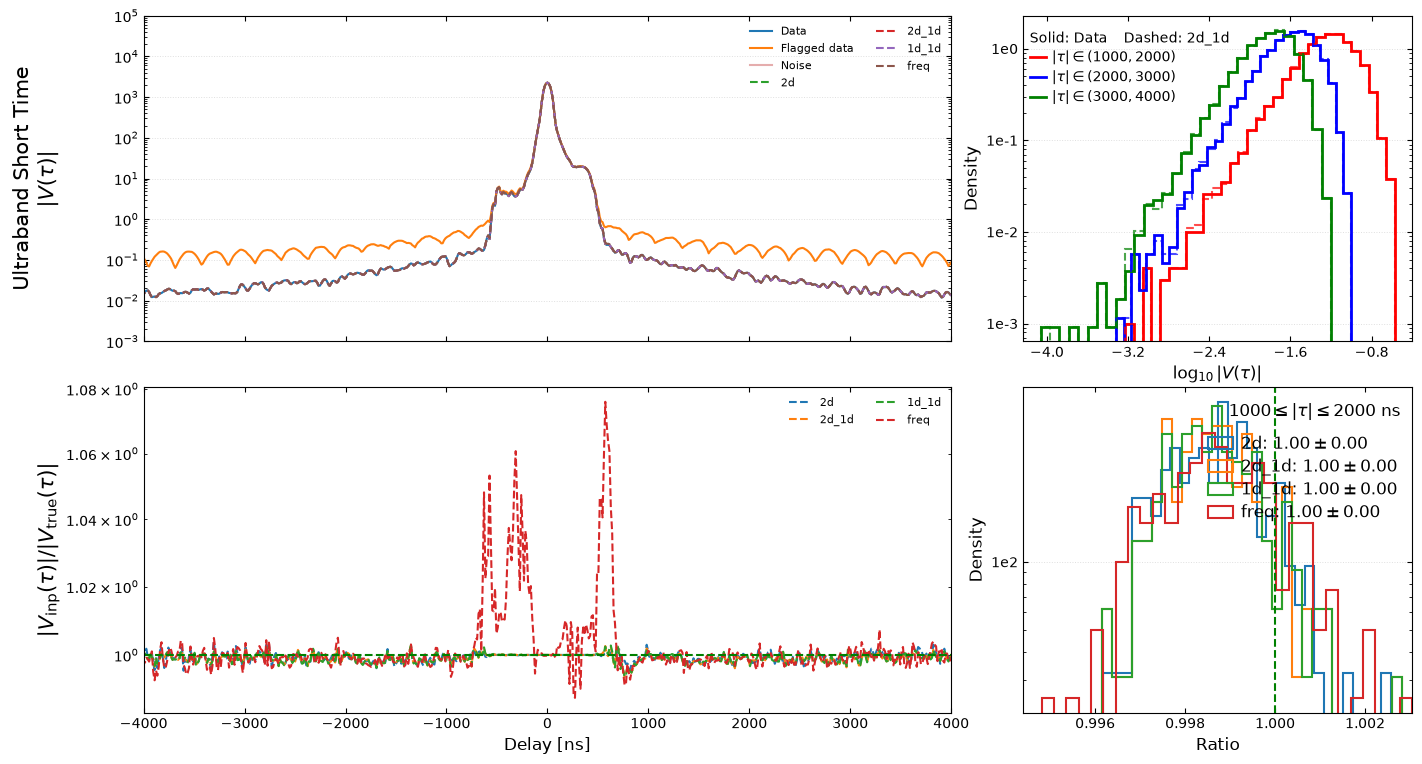

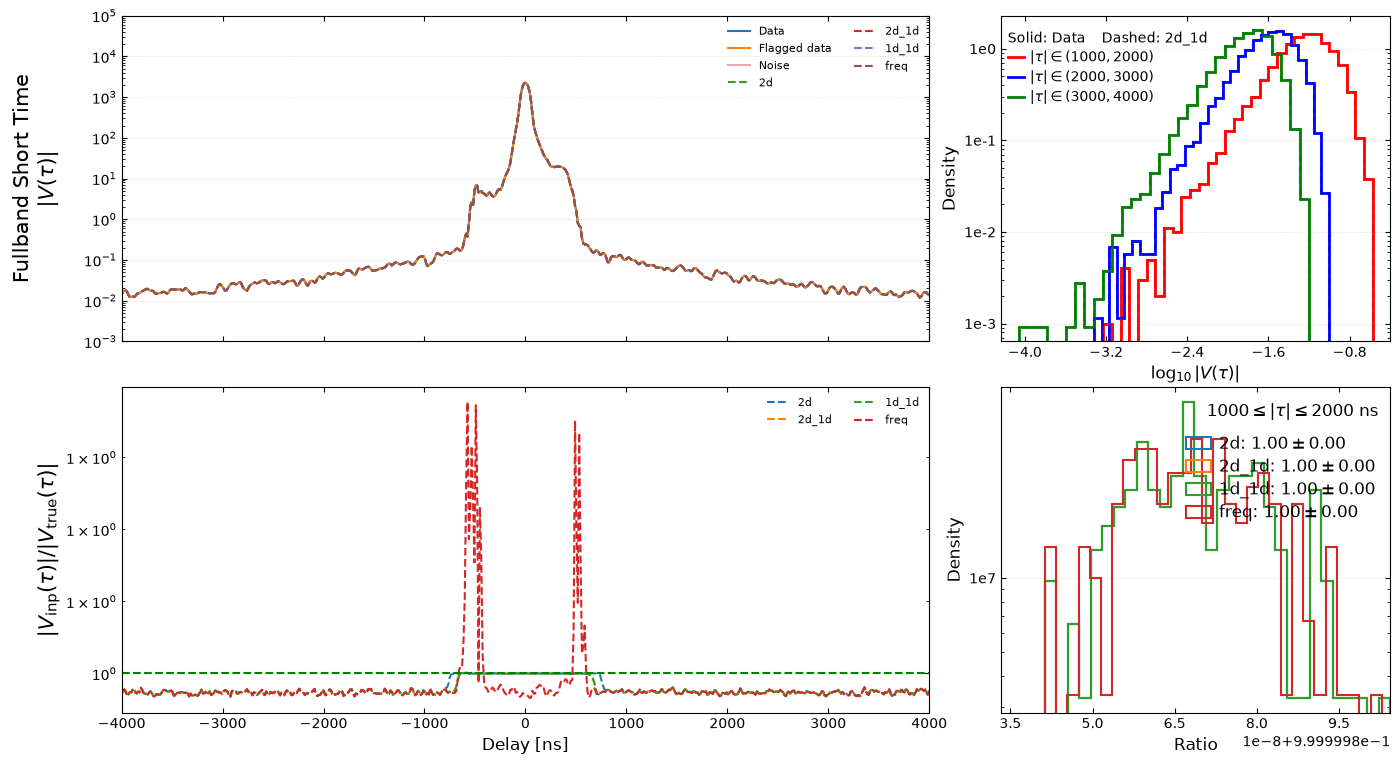

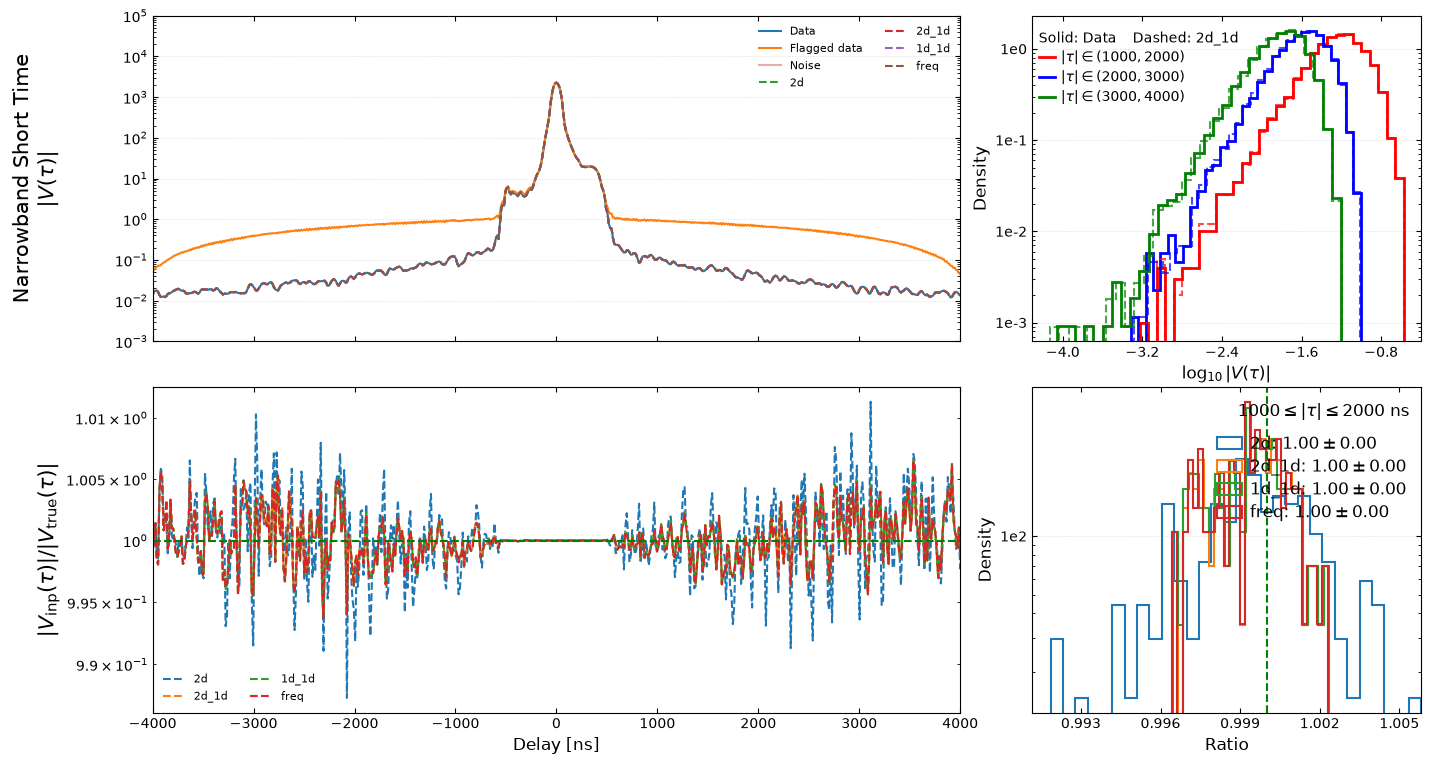

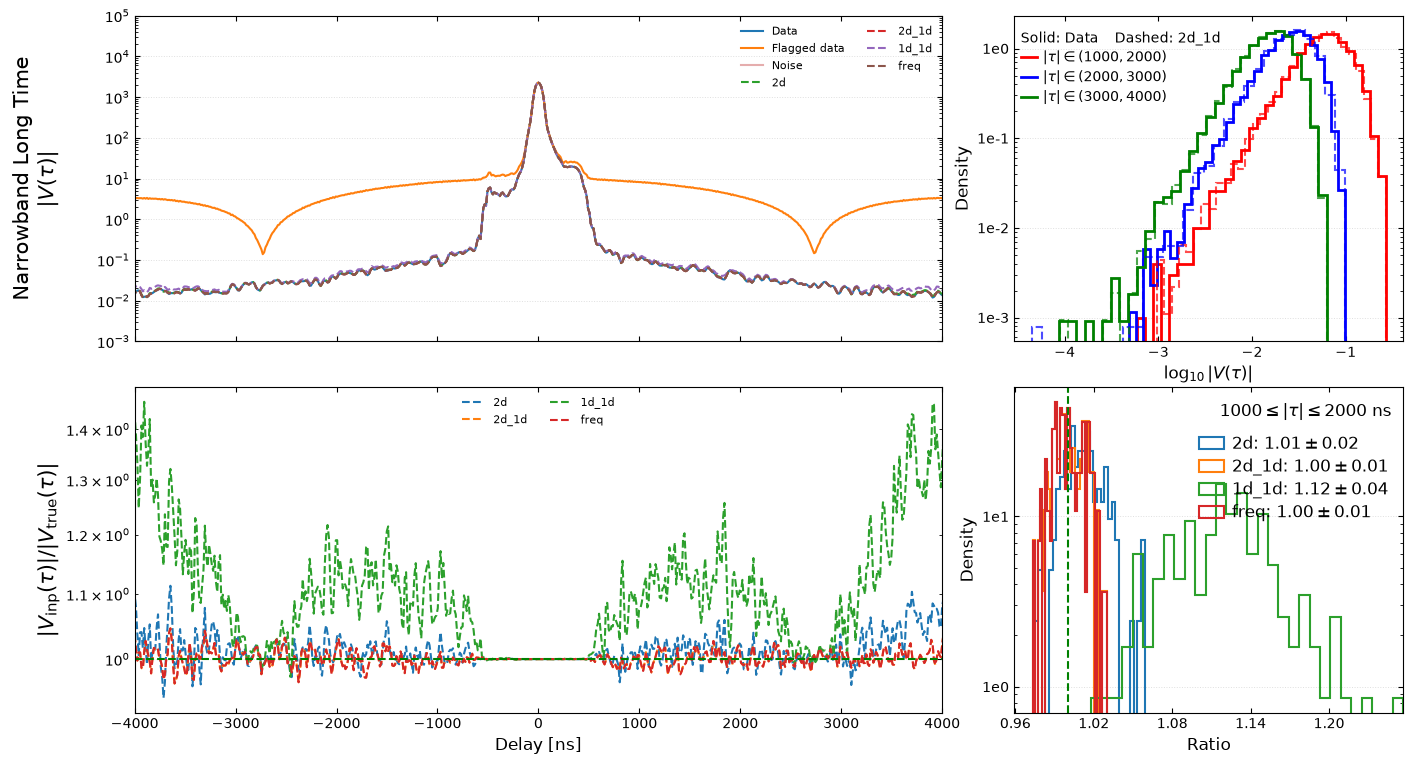

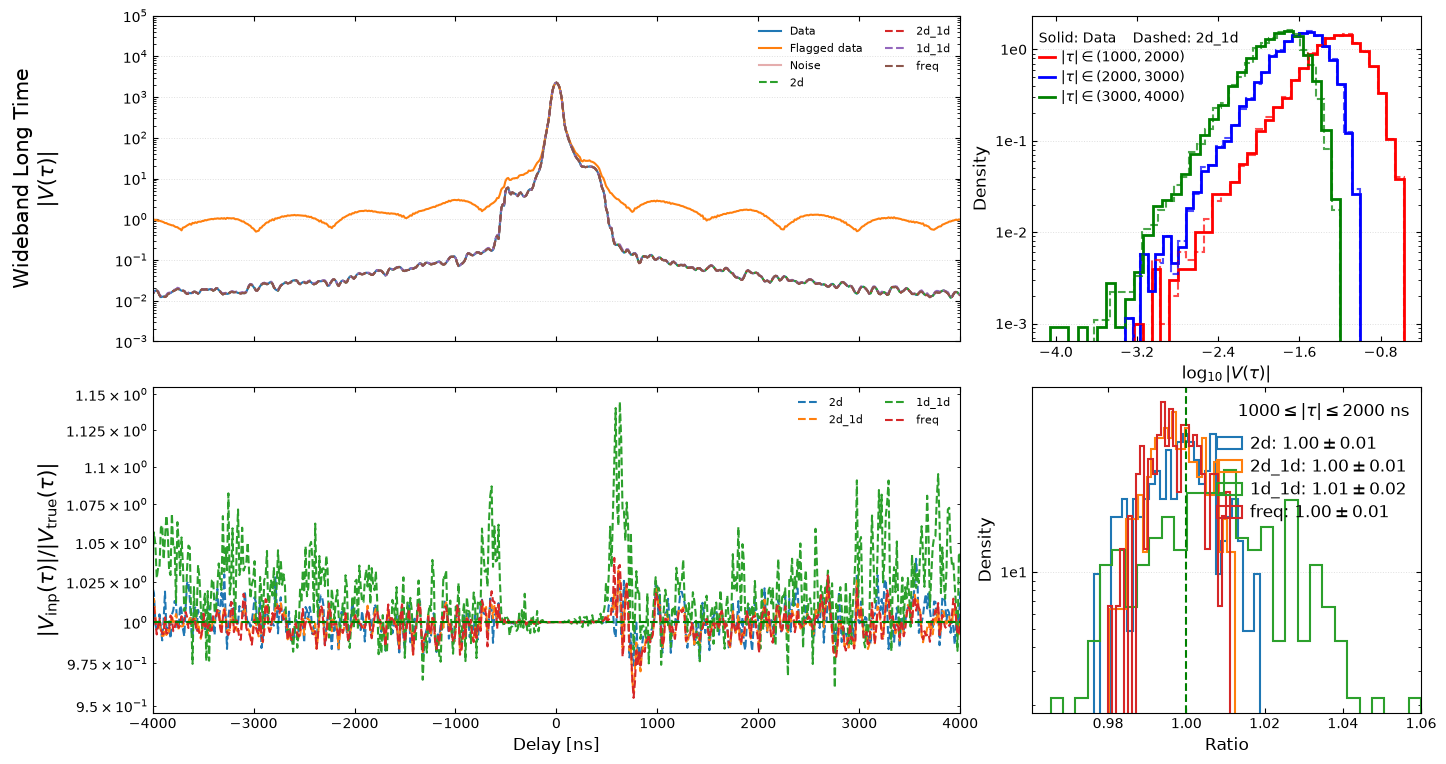

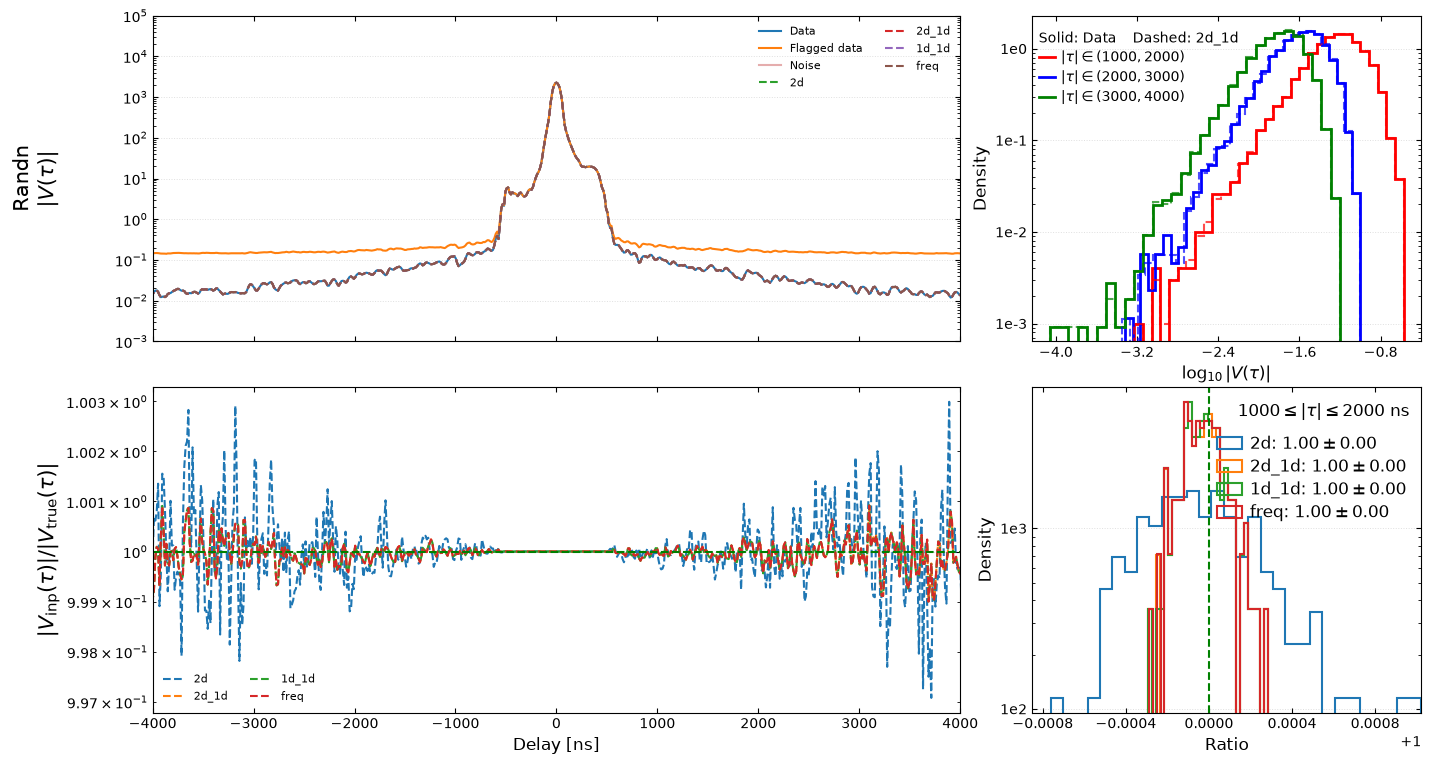

In [9]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import torch
import glob

import sys
sys.path.append('./')
import utils_load
from utils_load import save_vd_inp,load_vd_inp
from utils_Vtau import coherent_time_average
from pyuvdata import UVData
import bayeslim as ba

import gpytorch

import gprlim
from gprlim import kernels
from bayeslim.fft import FFT


torch.set_default_dtype(torch.float64)

sys.path.append('../')
import gp_utils
import importlib
importlib.reload(gp_utils)

import inspect
print("gprlim path:")
print(gprlim.__file__)

print("\nutils_inpaint module path:")
print(inspect.getmodule(save_vd_inp).__file__)

print("\ngp_utils path:")
print(gp_utils.__file__)

import importlib
import utils_Vtau

importlib.reload(utils_Vtau)

from utils_Vtau import (create_delay_figure, get_delay_quantities, plot_delay_histograms, get_ratio_hist_values, plot_reference_delay_curves, plot_method_curves,
                        plot_ratio_histogram, format_delay_axis, format_delay_hist_axis, format_ratio_axis, format_ratio_hist_axis, finalize_delay_figure)



def hera_inpaint(vd, flags, noise_var, times, freqs, time_kernel, freq_kernel, Ntime_chunks):
    Ntimes = len(times)
    vd_inp, vd_mdl = [], []
    
    c7=0
    for chunks in ba.utils.split_into_groups(np.arange(Ntimes), Nelem=Ntime_chunks):
        
        c7=c7+1
        print('chunk:',c7 )

        inp_y, mdl = gprlim.pipelines.hera_inpaint(
            vd.data[0, 0, :, chunks] * ~flags[:, chunks],
            noise_var[:, chunks],
            flags[:, chunks],
            times[chunks],
            freqs,
            time_kernel=time_kernel,
            freq_kernel=freq_kernel,
            bl_vec=bl_vec,    #136 change
            lat=meta['lat'],  #136 change
            norm_freq_alpha=norm_freq_alpha,
            inpaint=inpaint_method,
            flag_Ntimes=1000,
            fr_scale=fr_scale,
            fz_scale=fz_scale,
            fr_buffer=fr_buffer,
            pf_scale=pf_scale,
            wd_scale=wd_scale,
            lk_scale=lk_scale,
            lk_buffer=lk_buffer,
            kernel_var_mult=kernel_var_mult,
            noise_mult=100,
            #precond_2d='sparse_blockdiag',
            precond_2d='sparse_separable',
            sparse_rcond=1e-12,
            cg_tol=1e-3,
            red_avg_2d=False,
            n_threads=16,
            rcond_1d=1e-12,
        )

        # store the inpainted data
        _vd_inp = vd.select(time_inds=chunks, inplace=False)
        _vd_inp.data = inp_y[None, None]
        vd_inp.append(_vd_inp)
        _vd_mdl = vd.select(time_inds=chunks, inplace=False)
        _vd_mdl.data = mdl.expand(inp_y.shape)[None, None]
        vd_mdl.append(_vd_mdl)

    vd_inp = ba.dataset.concat_VisData(vd_inp, 'time')
    vd_mdl = ba.dataset.concat_VisData(vd_mdl, 'time')
    
    return vd_inp, vd_mdl






gpytorch.settings.max_cholesky_size._set_value(1_000)

torch.set_default_dtype(torch.float64)
device = 'cpu'



# 1. load all the data (except for the first 50 integrations which are wrong)
flag_file='gpr_data/version2/zen.h6c_idr3.2459951.flag_waterfall_round2.npz'
freq_chans = range(0, 600)
time_ints = range(80, 1680)

#2.
inflate_data = False
add_gains = False
add_noise = False
add_reflection = False



# 3.specify the inpaint method [ '2d','2d_1d', '1d_1d', 'freq', 'time']
#inpaint_method_all = ['1d_1d','2d_1d']
inpaint_method_all = [ '2d','2d_1d', '1d_1d', 'freq']  #136

# 4. specify the number of time chunks to operate over
Ntime_chunks = 200


#5.real falg
add_real_flags = False #

# 6.simulate flags, can add None+real
flag_types_all = [
    'narrowband_full_time',
    'wideband_full_time',  #136
    'ultraband_short_time',
    'fullband_short_time',
    'narrowband_short_time',
    'narrowband_long_time',
    'wideband_long_time',
    'randn',
]



#7. polo
polsi='ee'#,'nn'

# 8. baseline
blall=[(0, 1),(0, 5),(0, 10)]  #136

# 9.specify data
dfile = 'gpr_data/version2//zen.h6c_idr2_validation.sum.uvh5'
#dfile = sorted(glob.glob('gpr_data/version2/zen.h6c_idr2_validation.24582*.sum.coupled.h5'))



# load autocorrelation and metadata
vd, meta = gp_utils.load_uvdata(
    dfile, bls=[(0, 0)], pols=[polsi], time_ints=time_ints, freq_chans=freq_chans,
)
autocorr = vd.data[0,0]

freqs = meta['freqs'] / 1e6
lsts = meta['lsts']
times = (meta['times'] - meta['times'][0]) * 24 * 3600
Ntimes = len(times)
Nfreqs = len(freqs)
reds = meta['reds']

# get antenna information
antp = meta['antp']
ants = list(antp.keys())
antpos = torch.stack(list(antp.values()))

# get baseline information
red_bls = meta['bls']
all_pols = meta['pols']
reds = meta['reds']

# get noise standard deviation
noise_amp = autocorr.real / np.sqrt(np.diff(meta['times'])[0]*24*3600 * np.diff(meta['freqs'])[0])

# pick a representative baseline to load and model (start with 0)



for bl in blall:
    #bl = (0, 5)

    # this gets the index in the redundant set that this baseline falls in
    red_ind = np.where([bl in red for red in reds])[0][0]
    bls = reds[red_ind][:]
    bl_vec = antp[bls[0][1]] - antp[bls[0][0]]
    bl_len = bl_vec.norm()


    # load single baseline data
    vd, meta = gp_utils.load_uvdata(
        dfile,
        bls=bls,
        time_ints=time_ints,
        freq_chans=freq_chans,
        pols=[polsi], #['nn']
        device=device,
    )

    #inflate_data = True

    #False
    if inflate_data and vd.Nbls == 1:
        vd = vd.inflate_by_redundancy(bls=reds[red_ind])

    #add_reflection = False

    if add_reflection:
        vd.data *= (1 + 1e-2 * (torch.exp(2j*np.pi*2000e-9*freqs*1e6) + torch.exp(-2j*np.pi*2000e-9*freqs*1e6)))

    #add_gains = False
    #True
    if add_gains:
        G = torch.randn(vd.Nbls) / 10 + 1
        vd.data *= G[:, None, None]


    # fg 1e0
    #add_noise = False

    ns_draw = torch.randn_like(vd.data) * noise_amp * 1e-10  



    if add_noise:
        ns_draw = torch.randn_like(vd.data) * noise_amp * 1e-6
        vd.data += ns_draw




    # 1D FT across frequency
    FT1 = FFT(dim=-1, N=vd.data.shape[-1], ndim=2, window='bh', dx=(freqs[1]-freqs[0])/1e3)

    # 1D FT across time
    FT2 = FFT(dim=-2, N=vd.data.shape[-2], ndim=2, window='bh', dx=(lsts[1]-lsts[0])*12/np.pi*3600/1e3)






    # ============================================================
    # Simulate flags
    # ============================================================

    for flag_idx, flag_typesi in enumerate(flag_types_all):

        flag_types = [flag_typesi]
        flag_N = [20]

        # Figure title for the current flag type
        if add_real_flags:
            flag_title = f"Real Flags + {flag_typesi.replace('_', ' ').title()}"
        else:
            flag_title = flag_typesi.replace("_", " ").title()

        # Draw flags
        flags = gp_utils.simulate_flags(flag_types, flag_N, Ntimes, Nfreqs, seed=0)

        # If add_gains, draw new flags for each baseline
        if add_gains:

            flags = flags.expand(vd.data.shape[-3:]).clone()

            for i in range(1, vd.Nbls):
                flags[i] = gp_utils.simulate_flags(flag_types, flag_N, Ntimes, Nfreqs, seed=i)

        # Add real flags
        if add_real_flags:

            flg = np.load(flag_file)["flags"][time_ints][:, freq_chans, 0]
            flags += torch.as_tensor(flg, device=device)

        flagged_times = flags.all(dim=-1, keepdim=True).expand_as(flags)

        # Generate noise variance
        noise_var = noise_amp.pow(2).expand(flags.shape).clone() * 1e-5
        noise_var[flags] = noise_var.mean() * 1e6

        # ========================================================
        # Figure layout
        # ========================================================

        fig, ax_delay, ax_delay_hist, ax_ratio, ax_ratio_hist = create_delay_figure()

        hist_colors = ["r", "b", "g"]
        tau_ranges = [1000, 2000, 3000]

        # ========================================================
        # Loop over inpainting methods
        # ========================================================
        ratio_hist_all = []
        for inpaint_methodi in inpaint_method_all:

            inpaint_method = inpaint_methodi

            # Load data from Great Lakes
            vd_inp = load_vd_inp(
                root_dir="/Volumes/YUNYUNShao/radio_gpr_work_great_lake/1.shao/inpaint_results",
                vd=vd,
                bl=bl,
                flag_typesi=flag_typesi,
                add_real_flags=add_real_flags,
                inpaint_method=inpaint_method,
                freq_chans=freq_chans,
                time_ints=time_ints,
                polsi=polsi,
                device=device,
                Ntime_chunks=Ntime_chunks,
            )

            # Coherent time average
            vd_avg, vd_flg_avg, vd_inp_avg, vd_ns_avg = coherent_time_average(vd, vd_inp, flags, ns_draw, Ntimes, Nelem=20)

            # Delay-space quantities
            p_d, p_i, data_delay, flg_delay, inp_delay, ns_delay, delay, ratio = get_delay_quantities(vd_avg, vd_flg_avg, vd_inp_avg, vd_ns_avg, FT1)

            # Delay histograms
            plot_delay_histograms(ax_delay_hist, p_d, p_i, delay, inpaint_methodi, inpaint_method_all[0], tau_ranges, hist_colors)

            # Ratio histogram values
            ratio_hist = get_ratio_hist_values(ratio, delay, tau_min=1000, tau_max=2000)

            if ratio_hist.size > 0:
                ratio_hist_all.append(ratio_hist)

                ratio_mean = np.mean(ratio_hist)
                ratio_std = np.std(ratio_hist)

                method_label = (
                    f"{inpaint_methodi}: "
                    rf"${ratio_mean:.2f}\pm{ratio_std:.2f}$"
                )
            else:
                method_label = inpaint_methodi
                
                
            # Plot reference curves only once
            if inpaint_methodi == inpaint_method_all[0]:
                plot_reference_delay_curves(ax_delay, delay, data_delay, flg_delay, ns_delay)

            # Plot every inpainting method
            plot_method_curves(ax_delay, ax_ratio, delay, inp_delay, ratio, inpaint_methodi)

            # Plot every ratio histogram
            plot_ratio_histogram(ax_ratio_hist, ratio_hist, method_label)

        # ========================================================
        # Format all four subplots
        # ========================================================

        format_delay_axis(ax_delay, flag_title)
        format_delay_hist_axis(ax_delay_hist)
        format_ratio_axis(ax_ratio)
        format_ratio_hist_axis(
        ax_ratio_hist,
        ratio_hist_all=ratio_hist_all,
        #xmin=0.4,
        x_fraction=1.0,
        tau_min=1000,
        tau_max=2000,)

        # ========================================================
        # Final figure layout
        # ========================================================

        finalize_delay_figure(fig, ax_delay, ax_ratio, flag_idx, bl, polsi)

In [11]:
1

1